# TAREA 1: Simulación Monte Carlo --> Colisiones QED

## ***Objetivo***

generar 10,000 eventos aleatorios que sigan la distribución de probabilidad de colisiones en electrodinámica cuántica (qed).

**modelo:** $f(x) = 1 + x^2$, donde $x = \cos(\theta)$

**método:** rejection sampling

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parámetros
n_events = 10000
x_min, x_max = -1, 1  # cos(theta) en [-1, 1]

# función de distribución
def f(x):
    return 1 + x**2

## ***Rejection sampling***

el método de aceptación-rechazo **genera** eventos aleatorios siguiendo estos pasos:

1. proponer un valor aleatorio $x \in [-1, 1]$
2. proponer una altura aleatoria $y \in [0, f_{\text{max}}]$
3. si $y \leq f(x)$, aceptar el evento
4. si $y > f(x)$, rechazar y repetir

### ***la eficiencia es***

 $\eta = \frac{\text{área bajo } f(x)}{\text{área del rectángulo}}$

In [2]:
# máximo de f(x)
f_max = 2.0  # f(±1) = 1 + 1 = 2

# rejection sampling
accepted_events = []
n_attempts = 0

np.random.seed(42)

while len(accepted_events) < n_events:
    x_proposal = np.random.uniform(x_min, x_max) #propueesta de x en el rango [-1,1]
    y_proposal = np.random.uniform(0, f_max)  #propuesta de y en el rango [0,f_max]
    
    if y_proposal <= f(x_proposal):
        accepted_events.append(x_proposal)
    
    n_attempts += 1

accepted_events = np.array(accepted_events)
efficiency = n_events / n_attempts * 100

print(f"eventos generados: {len(accepted_events)}")
print(f"intentos totales: {n_attempts}")
print(f"eficiencia: {efficiency}%")

eventos generados: 10000
intentos totales: 15075
eficiencia: 66.33499170812604%



verificamos que **la distribución** tenga las propiedades esperadas:

- media cercana a 0 (por simetría)
- distribución tipo ***"U"*** (más eventos en los extremos)

In [3]:
print(f"media de x: {np.mean(accepted_events)}")
print(f"desviación estándar: {np.std(accepted_events)}")
print(f"rango: [{np.min(accepted_events)}, {np.max(accepted_events)}]")

media de x: -0.0001379880643351271
desviación estándar: 0.6282409908592556
rango: [-0.9999767304892677, 0.999849653666353]


## ***visualización:*** 

comparamos **los eventos simulados** con **la distribución teórica normalizada:**

$$f_{\text{norm}}(x) = \frac{1 + x^2}{\int_{-1}^{1} (1 + x^2) dx}$$

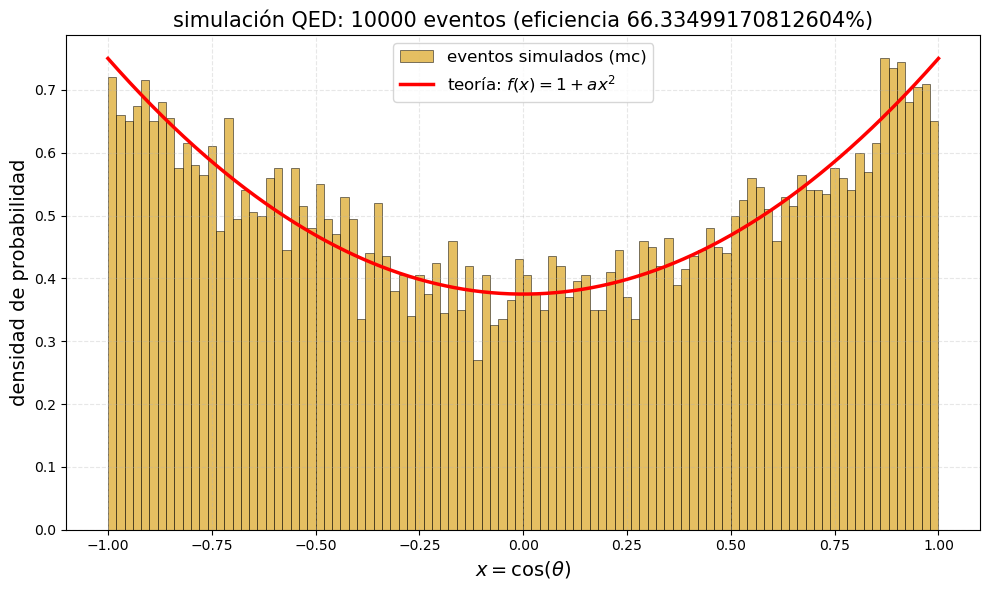

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# histograma de eventos simulados
ax.hist(accepted_events, bins=100, density=True, 
        alpha=0.7, color='goldenrod', 
        edgecolor='black', linewidth=0.5,
        label='eventos simulados (mc)')

# curva teórica
x_theory = np.linspace(x_min, x_max, 1000)
normalization = np.trapz(f(x_theory), x_theory)
f_normalized = f(x_theory) / normalization

ax.plot(x_theory, f_normalized, 'r-', linewidth=2.5, 
        label=r'teoría: $f(x) = 1 + ax^2$')

ax.set_xlabel(r'$x = \cos(\theta)$', fontsize=14)
ax.set_ylabel('densidad de probabilidad', fontsize=14)
ax.set_title(f'simulación QED: {n_events} eventos (eficiencia {efficiency:}%)',
             fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


verificamos los datos simulados con la teoría:

$$\chi^2 = \sum_i \frac{(O_i - E_i)^2}{E_i}$$

donde $O_i$ son los eventos observados y $E_i$ los esperados.

In [5]:
observed, bin_edges = np.histogram(accepted_events, bins=30, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

expected = f(bin_centers) / normalization * n_events * bin_width
chi2 = np.sum((observed - expected)**2 / expected)
ndof = len(observed) - 1

print(f"χ² = {chi2}")
print(f"ndof = {ndof}")
print(f"χ²/ndof = {chi2/ndof}")
print(f"\ncuando χ²/ndof ≈ 1 --> indica buen ajuste")

χ² = 25.81936610485189
ndof = 29
χ²/ndof = 0.8903229691328238

cuando χ²/ndof ≈ 1 --> indica buen ajuste


##  esta distribución ***modela*** la sección **eficaz diferencial:**

- **$\theta \to 0$** ($\cos\theta \to 1$): dispersión hacia adelante (***forward scattering***)
- **$\theta \to \pi$** ($\cos\theta \to -1$): retrodispersión (***backward scattering***)
- **$\theta \approx 90°$** ($\cos\theta \approx 0$): es menos probable


### **---- CASO 2 ----**
Suponemos que 

**modelo:** $f(x) = A(1 + x^2) + B*x$, donde $x = \cos(\theta)$

**método:** rejection sampling

Eventos generados: 10000
Intentos totales: 19793
Eficiencia: 50.522912140655784%
Media de x: 0.11868028890187161
Desviación estándar: 0.6160357375920803
Rango: [-0.999988926648524, 0.999849653666353]


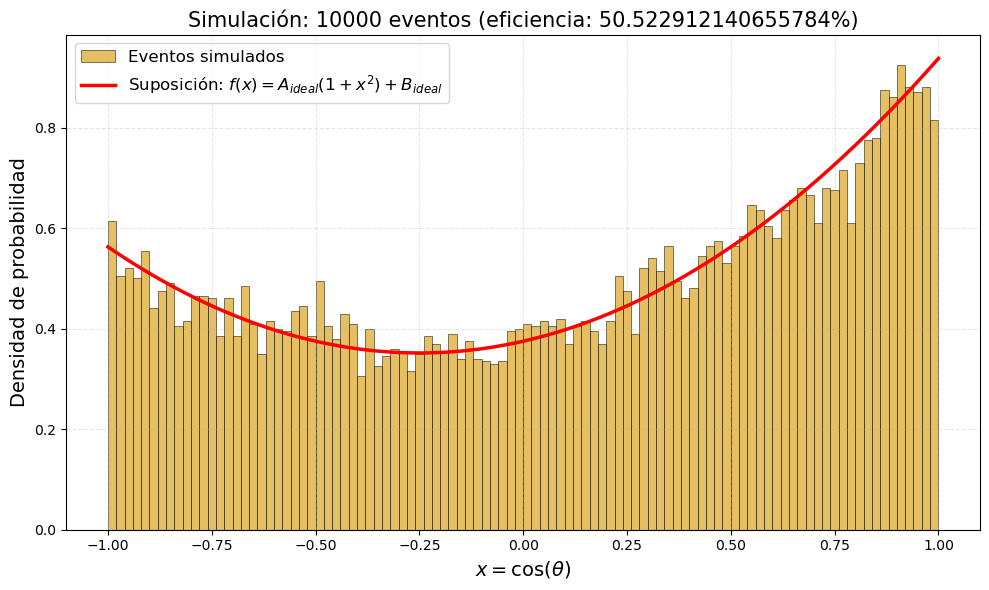

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# nuevos parametros
A_IDEAL= 1.0  # magnitud de la sección eficaz simétrica
B_IDEAL = 0.5  # término de asimetría adelante-atrás
n_events = 10000
x_min, x_max = -1, 1  # cos(theta) en [-1, 1]


def f(x, A, B):
    return A * (1 + x**2) + B * x


x_test = np.linspace(x_min, x_max, 1000)
f_max = np.max(f(x_test, A_IDEAL, B_IDEAL)) * 1.05 

# rejection sampling
accepted_events = []
n_attempts = 0

np.random.seed(42)

while len(accepted_events) < n_events:
    x_proposal = np.random.uniform(x_min, x_max)
    y_proposal = np.random.uniform(0, f_max)
    
    # pasamos A y B a la función
    if y_proposal <= f(x_proposal, A_IDEAL, B_IDEAL):
        accepted_events.append(x_proposal)
    
    n_attempts += 1

accepted_events = np.array(accepted_events)
efficiency = (n_events / n_attempts) * 100


# resultados
print(f"Eventos generados: {len(accepted_events)}")
print(f"Intentos totales: {n_attempts}")
print(f"Eficiencia: {efficiency}%") 
print(f"Media de x: {np.mean(accepted_events)}")
print(f"Desviación estándar: {np.std(accepted_events)}")
print(f"Rango: [{np.min(accepted_events)}, {np.max(accepted_events)}]") 


fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(accepted_events, bins=100, density=True, 
        alpha=0.7, color='goldenrod', 
        edgecolor='black', linewidth=0.5,
        label='Eventos simulados')

x_theory = np.linspace(x_min, x_max, 1000)
y_theory = f(x_theory, A_IDEAL, B_IDEAL)
normalization = np.trapz(y_theory, x_theory)
f_normalized = y_theory / normalization

ax.plot(x_theory, f_normalized, 'r-', linewidth=2.5, 
        label=r'Suposición: $f(x) = A_{ideal}(1 + x^2) + B_{ideal}$')

ax.set_xlabel(r'$x = \cos(\theta)$', fontsize=14)
ax.set_ylabel('Densidad de probabilidad', fontsize=14)
ax.set_title(f'Simulación: {n_events} eventos (eficiencia: {efficiency}%)', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## **CASO 3:** Definiendo valores para las funciones. 
### *(CASO NO CONSERVATIVO)*

Parámetros:

In [7]:
import numpy as np
# masa del bosón: Z (m_Z)
m_Z = 91.1876  # GeV
# anchura de la resonancia (Gamma_Z)
Gamma_Z = 2.4952  # GeV
# seno de wienberg (sin^2(theta_W)) 
s2w = 0.23126 
# e (carga del electrón) = ((4*pi)/(128))^2
e = np.sqrt(4 *np.pi /128)
# g (acoplamiento débil)
g = e /np.sqrt(s2w)
# ------------------------------- VALORES -------------------
#seno (sin(theta_W))
s_w = np.sqrt (0.23126)
#coseno (cos(theta_W))
c_w = np.sqrt(1 - s_w**2)
#---> coseno al cuadrado
c2W = c_w**2
#seno a la cuarta
s4w = s2w **2
# masa al cuadrado
mz2 = m_Z**2
#GAMMA AL CUADRADO
gamma= Gamma_Z**2

$A_{NC}= \frac{g^4 * s^2 (8 * sw^4 - 4 * sw^2 + 1)^2} {62 * cw^2 (\Gamma Z^2 * mz^2 + (s - mz^2)^2)} - \frac{(e * g^2 * s (1 - 4 * sw^2)^2 (s - mz^2)} {8 * cw(\Gamma Z^2 * mz^2 + (s - mz^2)^2)} + e^2$

$B_{NC}= - \frac{g^2 * s (g^2 * s(1 - 4 sw^4)^2 - 8 * cw * e(s - mz^2))}{32 * cw^2 (\Gamma Z^2 * mz^2 + (s - mz^2)^2)}$

In [8]:
A_NC =  ((g**4 * s2w * (8 * s4w - 4 * s2w + 1)**2) / (64 * c2W * (gamma * mz2 + (s_w - mz2)**2))) - ((e * g**2 * s_w * (1 - 4 * s2w)**2 * (s_w - mz2)**2) / (8 * c_w * (gamma * mz2 + (s_w - mz2)**2))) + e**2

B_NC = - ((g**2 * s_w * (g**2 * s_w * (1 - 4 * s4w)**2 - (8 * c_w * e * (s_w - mz2)))) / (32 * c2W * (gamma * mz2 + (s_w - mz2)**2)))

In [9]:
print(f"A_NC = {A_NC}")
print(f"B_NC = {B_NC}")


A_NC = 0.09812356642477735
B_NC = -2.191953307743763e-06


Eventos generados: 10000
Intentos totales: 15876
Eficiencia: 62.98815822625347%
Media de x: -0.001043680509730769
Desviación estándar: 0.6281352063679635
Rango: [-0.9999767304892677, 0.999849653666353]


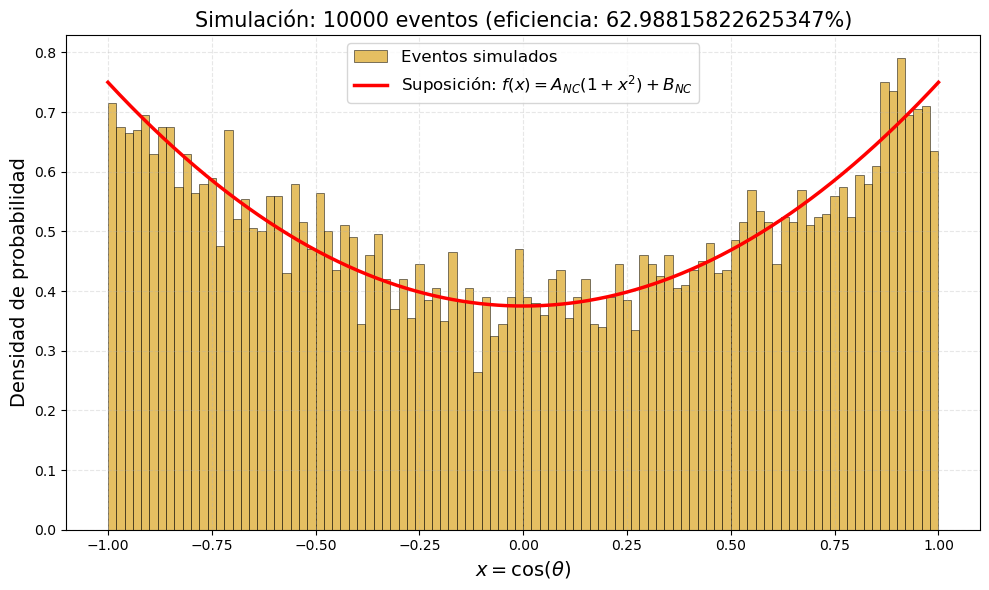

In [10]:
import matplotlib.pyplot as plt
# magnitud de la sección eficaz simétrica
A_NC = ((g**4 * s2w * (8 * s4w - 4 * s2w + 1)**2) / (64 * c2W * (gamma * mz2 + (s_w - mz2)**2))) - ((e * g**2 * s_w * (1 - 4 * s2w)**2 * (s_w - mz2)**2) / (8 * c_w * (gamma * mz2 + (s_w - mz2)**2))) + e**2
# término de asimetría adelante-atrás
B_NC =  - ((g**2 * s_w * (g**2 * s_w * (1 - 4 * s4w)**2 - (8 * c_w * e * (s_w - mz2)))) / (32 * c2W * (gamma * mz2 + (s_w - mz2)**2)))
n_events = 10000
x_min, x_max = -1, 1  # cos(theta) en [-1, 1]


def f(x, A_NC, B_NC):
    return A_NC * (1 + x**2) + B_NC * x


x_test = np.linspace(x_min, x_max, 1000)
f_max = np.max(f(x_test, A_NC, B_NC)) * 1.05

# rejection sampling
accepted_events = []
n_attempts = 0

np.random.seed(42)

while len(accepted_events) < n_events:
    x_proposal = np.random.uniform(x_min, x_max)
    y_proposal = np.random.uniform(0, f_max)
    
    # pasamos A y B a la función
    if y_proposal <= f(x_proposal, A_NC, B_NC):
        accepted_events.append(x_proposal)
    
    n_attempts += 1

accepted_events = np.array(accepted_events)
efficiency = (n_events / n_attempts) * 100


# resultados
print(f"Eventos generados: {len(accepted_events)}")
print(f"Intentos totales: {n_attempts}")
print(f"Eficiencia: {efficiency}%") 
print(f"Media de x: {np.mean(accepted_events)}")
print(f"Desviación estándar: {np.std(accepted_events)}")
print(f"Rango: [{np.min(accepted_events)}, {np.max(accepted_events)}]") 


fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(accepted_events, bins=100, density=True, 
        alpha=0.7, color='goldenrod', 
        edgecolor='black', linewidth=0.5,
        label='Eventos simulados')

x_theory = np.linspace(x_min, x_max, 1000)
y_theory = f(x_theory, A_NC, B_NC)
normalization = np.trapz(y_theory, x_theory)
f_normalized = y_theory / normalization

ax.plot(x_theory, f_normalized, 'r-', linewidth=2.5, 
        label=r'Suposición: $f(x) = A_{NC}(1 + x^2) + B_{NC}$')

ax.set_xlabel(r'$x = \cos(\theta)$', fontsize=14)
ax.set_ylabel('Densidad de probabilidad', fontsize=14)
ax.set_title(f'Simulación: {n_events} eventos (eficiencia: {efficiency}%)', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## **CHEQUEO:** Tarea 3


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---- parámetros (GeV) ----

m_Z = 91.1876     # masa del bosón Z en 
Gamma_Z = 2.4952  # anchura de resonancia 
s2w = 0.23126     # sin^2(theta_W)

# acoplamientos y cargas
e = np.sqrt(4 * np.pi / 128)
g = e / np.sqrt(s2w)

# relaciones trigonométricas
s_w = np.sqrt(s2w)
c_w = np.sqrt(1 - s2w)
c2W = c_w**2
s4w = s2w**2

# variables al cuadrado 
mz2 = m_Z**2
gamma = Gamma_Z**2  
s = (m_Z + 291)**2   # --> energía en el centro de masa al cuadrado, donde 4 es un valor arbitraio cercano a la resonancia. pero no se como ??

In [12]:
# ---- ecuaciones -----
# denominador común
denominador = (gamma * mz2) + (s - mz2)**2

# simétria: A_NC
A_term1 = (g**4 * s**2 * (8 * s4w - 4 * s2w + 1)**2) / (64 * c2W * denominador)
A_term2 = (e * g**2 * s * (1 - 4 * s2w)**2 * (s - mz2)) / (8 * c_w * denominador)
A_NC = A_term1 - A_term2 + e**2

# asimetría: B_NC
B_num = g**2 * s * (g**2 * s * (1 - 4 * s2w)**2 - 8 * c_w * e * (s - mz2))
B_den = 32 * c2W * denominador
B_NC = - (B_num / B_den)

print(f"Coeficiente A_NC: {A_NC}")
print(f"Coeficiente B_NC: {B_NC}\n")

Coeficiente A_NC: 0.09910303107970317
Coeficiente B_NC: 0.040170106741210826



In [13]:
# ---- rejection sampling -----
def f(x, A, B):
    return A * (1 + x**2) + B * x

n_events = 10000
x_min, x_max = -1, 1

x_test = np.linspace(x_min, x_max, 1000)
f_max = np.max(f(x_test, A_NC, B_NC)) * 1.05

accepted_events = []
n_attempts = 0

np.random.seed(42)

while len(accepted_events) < n_events:
    x_proposal = np.random.uniform(x_min, x_max)
    y_proposal = np.random.uniform(0, f_max)
    
    if y_proposal <= f(x_proposal, A_NC, B_NC):
        accepted_events.append(x_proposal)
    
    n_attempts += 1

accepted_events = np.array(accepted_events)
efficiency = (n_events / n_attempts) * 100

Eventos Generados: 10000
Intentos Totales: 19044
Eficiencia: 52.509976895610166%
Media de X: 0.09479676950765693


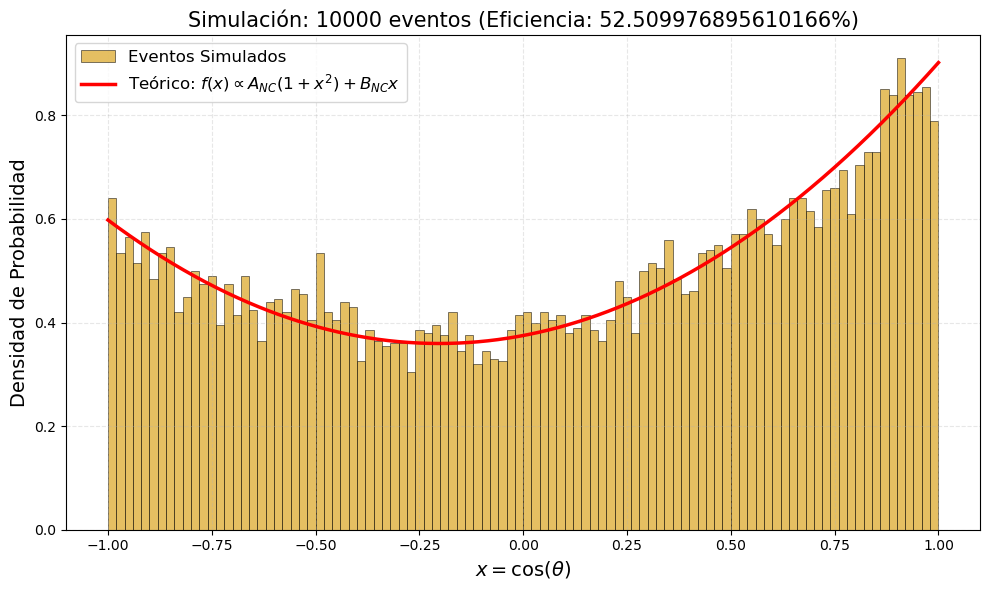

In [14]:
#-------- resultados------

print(f"Eventos Generados: {len(accepted_events)}")
print(f"Intentos Totales: {n_attempts}")
print(f"Eficiencia: {efficiency}%") 
print(f"Media de X: {np.mean(accepted_events)}")

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(accepted_events, bins=100, density=True, 
        alpha=0.7, color='goldenrod', 
        edgecolor='black', linewidth=0.5,
        label='Eventos Simulados')

# curva teórica superpuesta
x_theory = np.linspace(x_min, x_max, 1000)
y_theory = f(x_theory, A_NC, B_NC)
normalization = np.trapz(y_theory, x_theory)
f_normalized = y_theory / normalization

ax.plot(x_theory, f_normalized, 'r-', linewidth=2.5, 
        label=r'Teórico: $f(x) \propto A_{NC}(1 + x^2) + B_{NC}x$')

ax.set_xlabel(r'$x = \cos(\theta)$', fontsize=14)
ax.set_ylabel('Densidad de Probabilidad', fontsize=14)
ax.set_title(f'Simulación: {n_events} eventos (Eficiencia: {efficiency}%)', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()